# UrbanHeat AI: The Pearl planning pilot

Team Al Zubarah (الزبارة), Qatar. Theme: Urban Expansion, Land Use Change & Heat Risk.

This PoC screens a small analyst-defined area for further urban-planning investigation. It combines morning satellite surface temperature, green-pixel share, contributed building footprints and historical machine-learning-derived land cover. It does not estimate heat-health risk or run our own building-segmentation model.

Run every cell in order. All sample data are included, so no download or account is required.

In [1]:
from pathlib import Path
import runpy, json, contextlib, io
from IPython.display import display, Image
ROOT = Path.cwd()
assert (ROOT / "src/export_map.py").exists(), "Open this notebook from the repository root."
assert (ROOT / "data/sample_input/reference/worldcover2021.tif").exists()

## Sources and parameters

Sentinel-2 L2A: 5, 15 and 30 September 2026. Landsat L2 surface temperature: 6, 14 and 30 September 2026. Accepted thermal comparison dates are 14 and 30 September. Optical matching differs by one day on 14 September.

ESA WorldCover v200 refers to 2021, and provides historical context. OpenStreetMap geometry was downloaded on 4 October 2026 and contains contributed mapping with varying edit dates.

Main filters: clear optical land on all dates, union of water candidates, 60 m water exclusion plus a 60 m crop-edge exclusion, at least 90% inland optical support, ST_QA ≤2 K, cloud distance ≥1 km and valid thermal QA. Retained 300 m cells require at least 25 delivered 30 m samples. Samples do not provide independent 30 m thermal information.

In [2]:
with contextlib.redirect_stdout(io.StringIO()):
    pipeline = runpy.run_path(str(ROOT / "src/export_map.py"))
planning = pipeline["planning"]["report"]
summary = pipeline["data"]["report"]
print(f"Common footprint: {planning['common_footprint_km2']:.2f} km²")
print(f"Reported cells: {planning['reported_cells']}")
print("Thermal dates:", ", ".join(summary["accepted_thermal_dates"]))
print("First investigation candidates:", ", ".join(p["cell_id"] for p in planning["top3"]))

Common footprint: 1.15 km²
Reported cells: 16
Thermal dates: 2026-09-14, 2026-09-30
First investigation candidates: V02-05, V04-04, V04-03


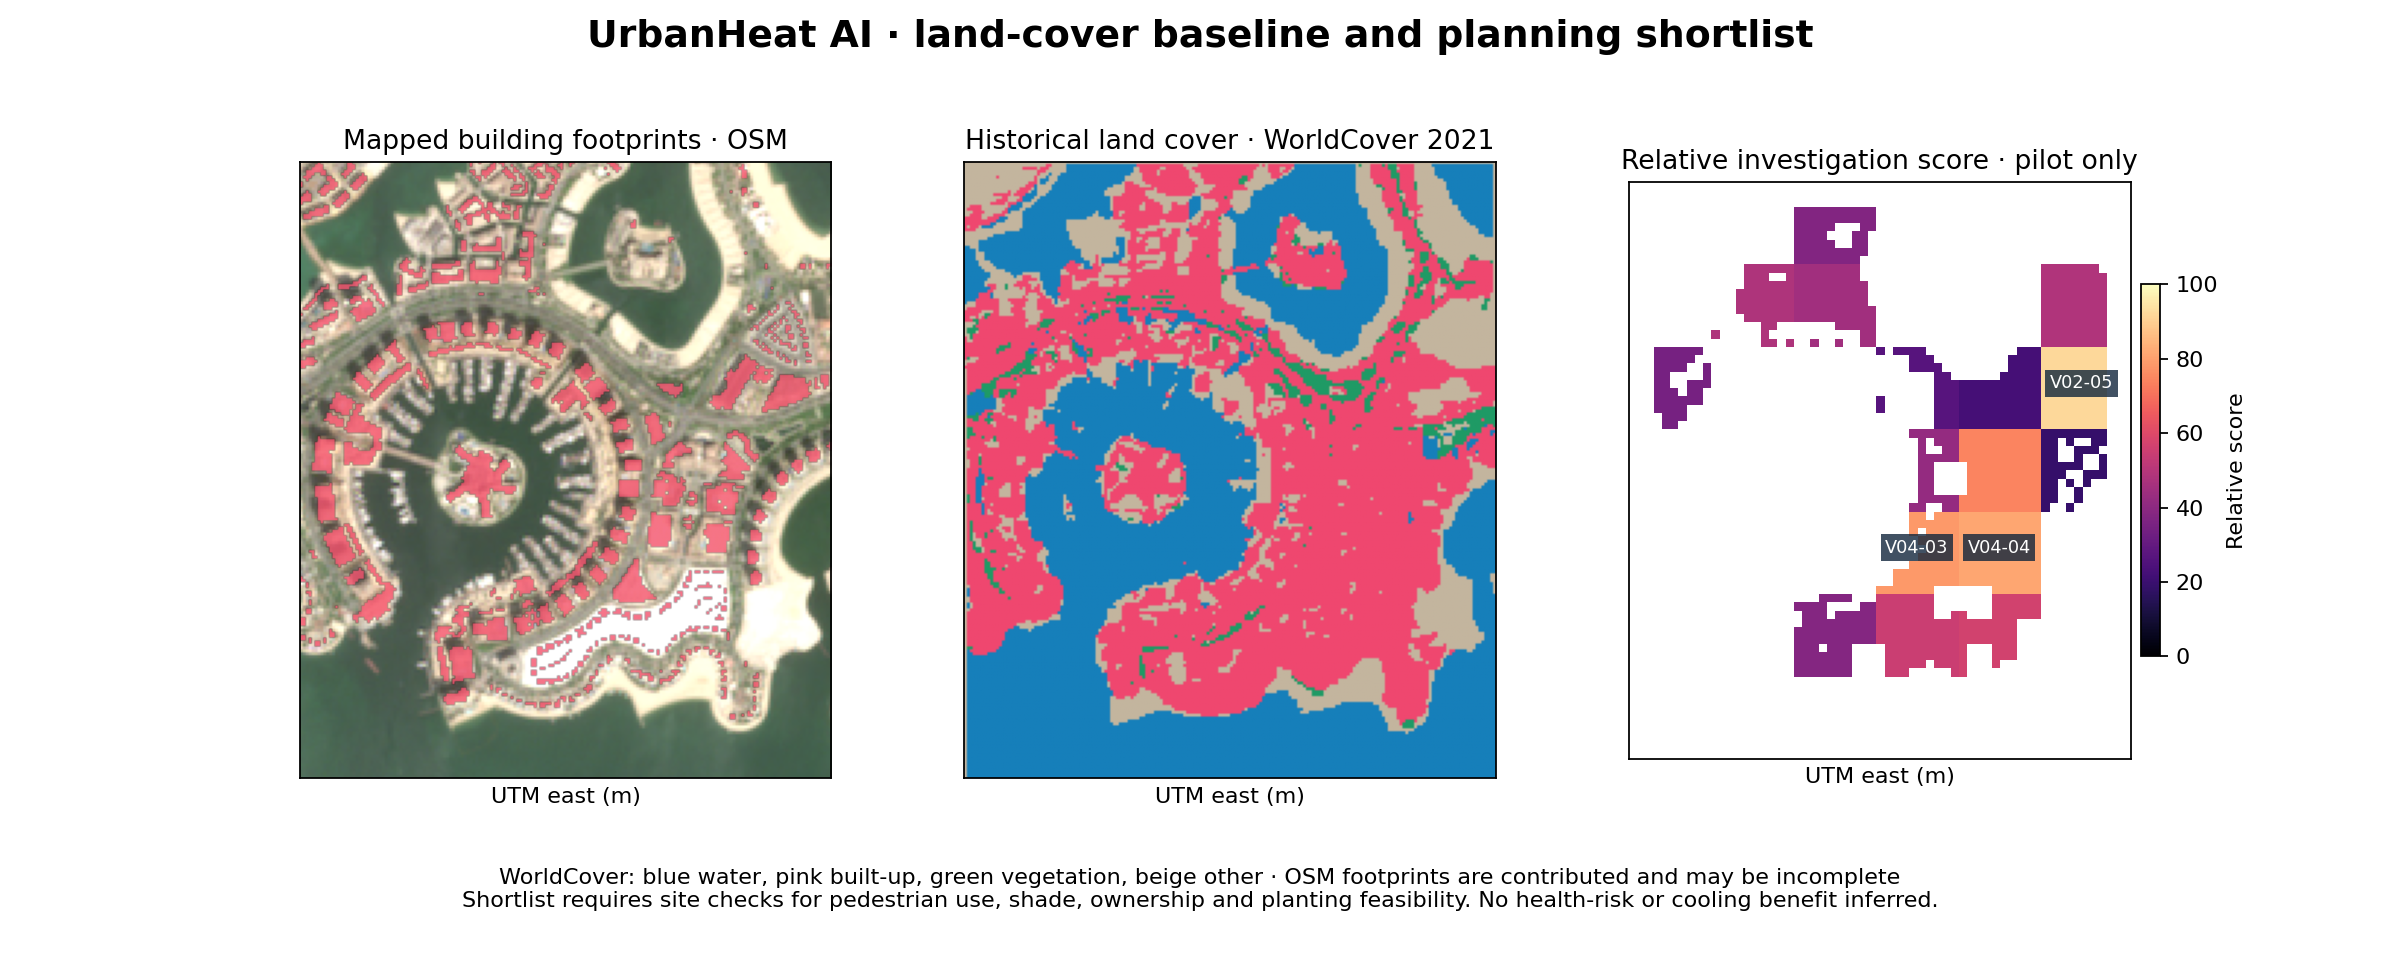

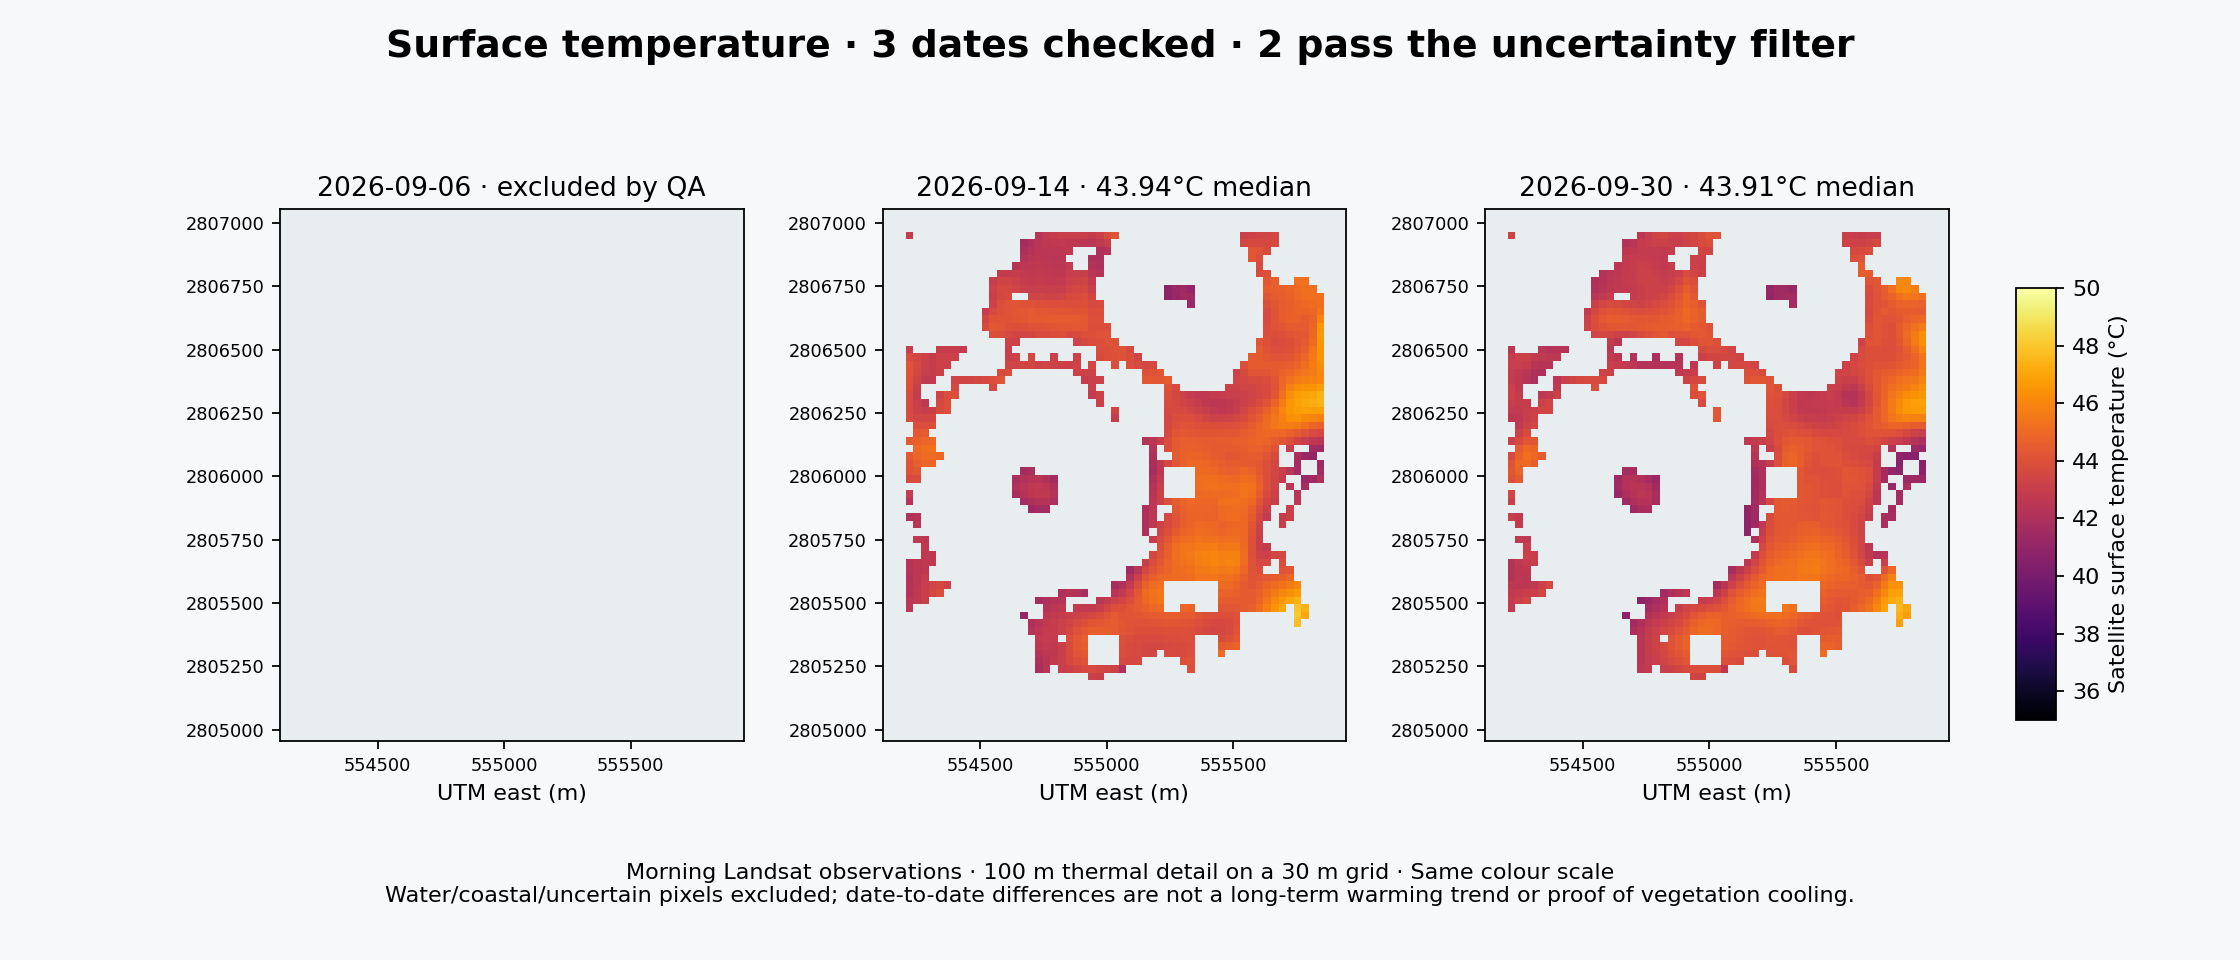

In [3]:
display(Image(filename=str(ROOT / "results/planning-map.png")))
display(Image(filename=str(ROOT / "results/multidate-temperature.png")))

## Reference checks and sensitivity

Reference labels come from contributed OSM geometry rather than the satellite prediction. These positive-reference checks are limited in coverage and are not a representative accuracy assessment. Thirty spaced points offshore of mapped coastlines agree with the water screen. Three sampled small mapped water features are missed. No grass interiors survive a 10 m erosion. Human reference confirmation and independent thermal calibration remain pending. WorldCover uses some OSM auxiliary inputs, so building agreement is not independent WorldCover model validation.

The investigation score uses relative percentile ranks: 50% surface temperature, 30% inverse green-pixel share and 20% mapped building share. Eleven settings test NDVI thresholds, water buffers, QA limits, cell coverage and weights. This deterministic heuristic produces a shortlist for site inspection. It does not quantify human exposure or intervention benefits.

In [4]:
for check in planning["reference_checks"]:
    print(check)
for p in planning["top3"]:
    print(p["cell_id"], "rank range", p["scenario_best_rank"], "to", p["scenario_worst_rank"], "across", p["scenarios_eligible"], "settings")

{'reference_class': 'building', 'eligible_core_10m_pixels': 1010, 'spaced_samples': 30, 'screened_water_percent': 0.0, 'ndvi_green_percent': 3.3, 'worldcover_built_up_percent': 83.3}
{'reference_class': 'water', 'eligible_core_10m_pixels': 14, 'spaced_samples': 3, 'screened_water_percent': 0.0, 'ndvi_green_percent': 0.0, 'worldcover_built_up_percent': 33.3}
{'reference_class': 'grass', 'eligible_core_10m_pixels': 0, 'spaced_samples': 0, 'screened_water_percent': None, 'ndvi_green_percent': None, 'worldcover_built_up_percent': None}
{'reference_class': 'coastal_water', 'eligible_core_10m_pixels': None, 'spaced_samples': 30, 'screened_water_percent': 100.0, 'ndvi_green_percent': 0.0, 'worldcover_built_up_percent': None}
V02-05 rank range 1 to 1 across 11 settings
V04-04 rank range 2 to 3 across 11 settings
V04-03 rank range 2 to 6 across 11 settings


## Readiness checks

The next cell verifies sample support, thermal scaling and QA, score range, row counts and reference sample provenance. Temperature product uncertainty is not a confidence interval for a cell median, and does not capture all possible systematic errors. The two accepted September morning dates cannot establish a trend or causal vegetation cooling.

In [5]:
verification = runpy.run_path(str(ROOT / "src/verify.py"))
print("Scientific and file checks passed.")

{"samples": 1278, "cells": 16, "source_checks": 63, "status": "pass"}
Scientific and file checks passed.


## Outputs and interpretation

Results are under `results/`. `planning-cells.csv` and GeoJSON contain cell values, ranks, observed coverage and sensitivity ranges. `reference-samples.csv` contains explicit source references and pending human confirmation fields. `app/assets/` holds regenerated map data and raster layers.

Before intervention, inspect pedestrian use, current shade, ownership, planting feasibility and the age/completeness of mapped buildings. VHR segmentation, paved-surface separation, population and independent thermal validation are future extensions. See README.md for licences, reproduction and submission readiness.